In [1]:
# ============================================================
# WEEK 12 FINAL CAPSTONE PROJECT
# Comprehensive Data Science Project
# Business Problem: Customer Churn Risk Prediction & Business Growth Analysis
# Author: Meda Venkata Lakshmi Divya
# Environment: Google Colab
# ============================================================

# ------------------------------------------------
# Cell 1: Upload Required Datasets
# ------------------------------------------------

from google.colab import files

uploaded = files.upload()

# Upload:
# 1. customer_churn.csv
# 2. sales_data.csv
# 3. house_prices.csv

Saving customer_churn.csv to customer_churn.csv
Saving house_prices.csv to house_prices.csv
Saving sales_data.csv to sales_data.csv


In [2]:
# ------------------------------------------------
# Cell 2: Import Required Libraries
# ------------------------------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

sns.set_theme(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# ------------------------------------------------
# Cell 3: Load Datasets
# ------------------------------------------------

customer_df = pd.read_csv("customer_churn.csv")
sales_df = pd.read_csv("sales_data.csv")
house_df = pd.read_csv("house_prices.csv")

print("Datasets loaded successfully")

print("Customer Churn Dataset:", customer_df.shape)
print("Sales Dataset:", sales_df.shape)
print("House Prices Dataset:", house_df.shape)

customer_df.head()

Datasets loaded successfully
Customer Churn Dataset: (500, 9)
Sales Dataset: (100, 7)
House Prices Dataset: (300, 8)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [4]:
# ------------------------------------------------
# Cell 4: Data Quality Check
# ------------------------------------------------

def dataset_summary(df, name):
    print("=" * 50)
    print(name)
    print("=" * 50)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns)
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nDuplicate Rows:", df.duplicated().sum())

dataset_summary(customer_df, "Customer Churn Dataset")
dataset_summary(sales_df, "Sales Dataset")
dataset_summary(house_df, "House Prices Dataset")

Customer Churn Dataset
Shape: (500, 9)

Columns:
Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='object')

Missing Values:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

Duplicate Rows: 0
Sales Dataset
Shape: (100, 7)

Columns:
Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')

Missing Values:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Duplicate Rows: 0
House Prices Dataset
Shape: (300, 8)

Columns:
Index(['Property_ID', 'Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location',
       'Property_Type', 'Price'],
      dtype='object')

Missing Values:
Property_ID    

In [5]:
# ------------------------------------------------
# Cell 5: Data Cleaning
# ------------------------------------------------

# Remove duplicate rows
customer_df = customer_df.drop_duplicates()
sales_df = sales_df.drop_duplicates()
house_df = house_df.drop_duplicates()

# Convert TotalCharges to numeric
customer_df["TotalCharges"] = pd.to_numeric(
    customer_df["TotalCharges"],
    errors="coerce"
)

# Fill missing numerical values
for col in customer_df.select_dtypes(include=np.number).columns:
    customer_df[col] = customer_df[col].fillna(customer_df[col].median())

# Fill missing categorical values
for col in customer_df.select_dtypes(include="object").columns:
    customer_df[col] = customer_df[col].fillna(customer_df[col].mode()[0])

# Save cleaned customer data
customer_df.to_csv("cleaned_customer_data.csv", index=False)

print("Data cleaning completed successfully")

Data cleaning completed successfully


In [6]:
# ------------------------------------------------
# Cell 6: Feature Engineering
# ------------------------------------------------

# Customer Lifetime Value
customer_df["Customer_Lifetime_Value"] = (
    customer_df["Tenure"] * customer_df["MonthlyCharges"]
)

# Average revenue per tenure
customer_df["Avg_Revenue_Per_Tenure"] = (
    customer_df["TotalCharges"] / (customer_df["Tenure"] + 1)
)

# Tenure group
customer_df["Tenure_Group"] = pd.cut(
    customer_df["Tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"],
    include_lowest=True
)

# Contract risk
customer_df["Contract_Risk"] = np.where(
    customer_df["Contract"] == "Month-to-month",
    "High Risk",
    "Low Risk"
)

# High value customer
customer_df["High_Value_Customer"] = np.where(
    customer_df["TotalCharges"] > customer_df["TotalCharges"].median(),
    1,
    0
)

print("Feature engineering completed successfully")

customer_df.head()

Feature engineering completed successfully


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,Customer_Lifetime_Value,Avg_Revenue_Per_Tenure,Tenure_Group,Contract_Risk,High_Value_Customer
0,C00001,6,64,1540,One year,Credit Card,No,1,0,384,220.000000,0-12 Months,Low Risk,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0,2373,79.681818,13-24 Months,High Risk,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0,837,51.964286,25-48 Months,Low Risk,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0,1537,132.407407,49-72 Months,High Risk,1
4,C00005,16,185,1023,One year,Electronic Check,No,1,0,2960,60.176471,13-24 Months,Low Risk,0


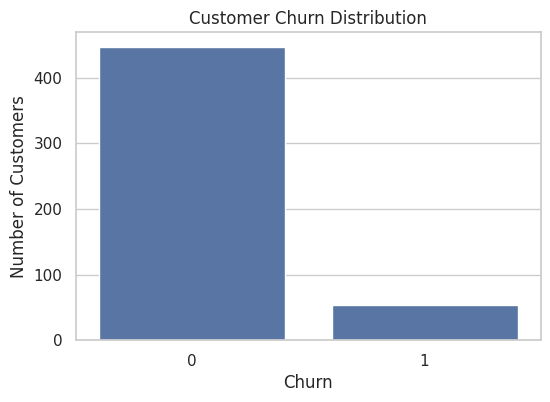

In [7]:
# ------------------------------------------------
# Cell 7: Exploratory Data Analysis - Churn Distribution
# ------------------------------------------------

plt.figure(figsize=(6, 4))

sns.countplot(
    x="Churn",
    data=customer_df
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

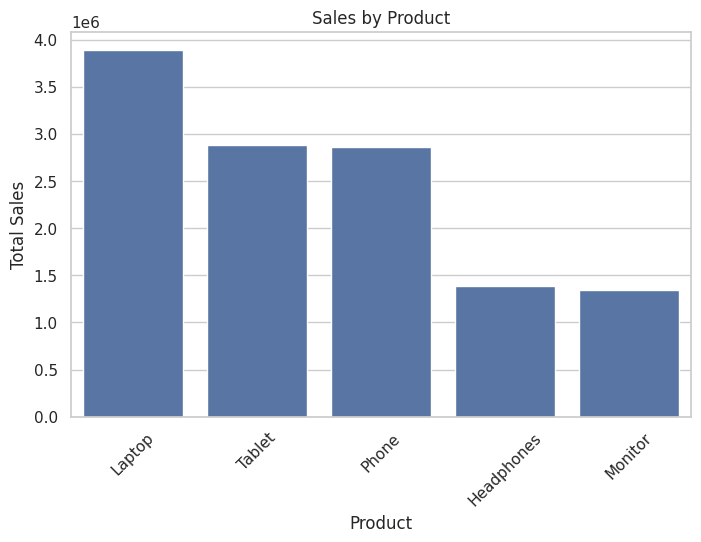

In [8]:
# ------------------------------------------------
# Cell 8: Exploratory Data Analysis - Sales by Product
# ------------------------------------------------

product_sales = sales_df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=product_sales.index,
    y=product_sales.values
)

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

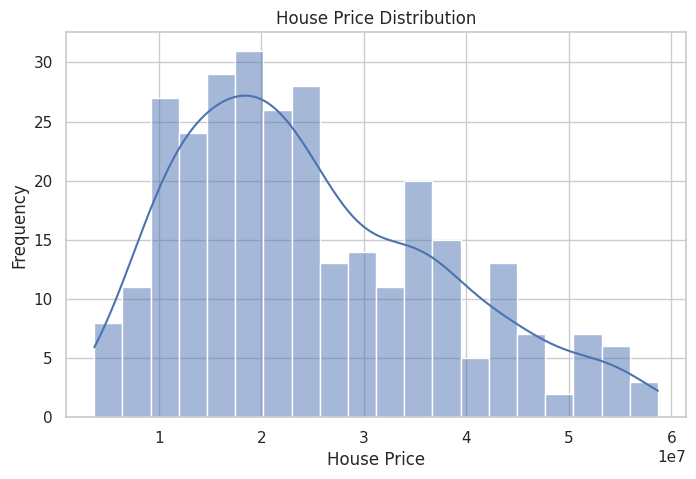

In [9]:
# ------------------------------------------------
# Cell 9: Exploratory Data Analysis - House Price Distribution
# ------------------------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    house_df["Price"],
    kde=True,
    bins=20
)

plt.title("House Price Distribution")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

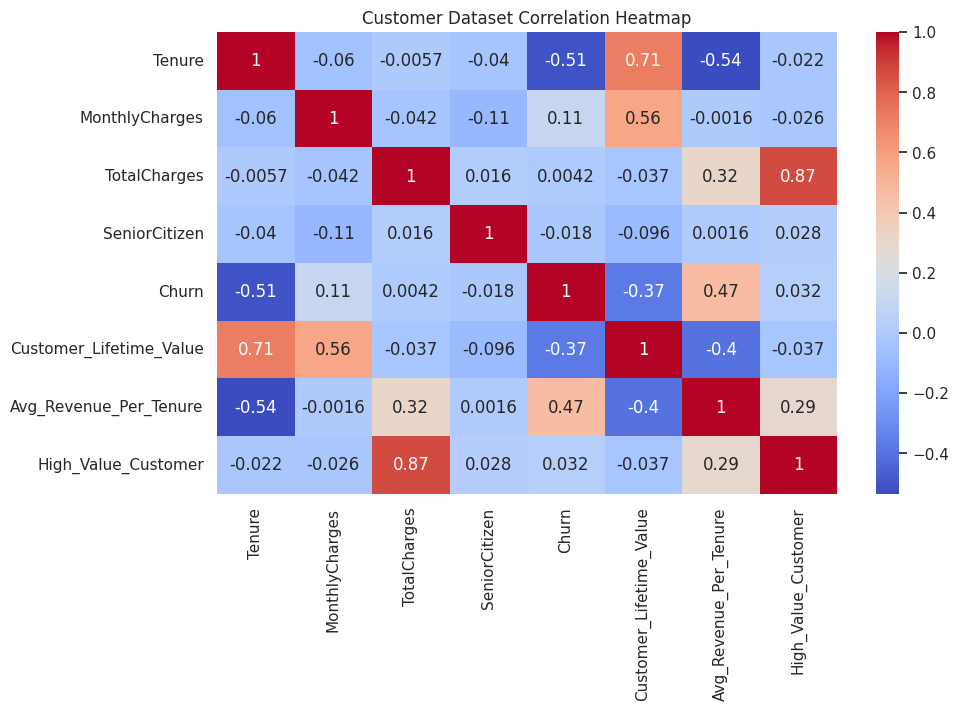

In [10]:
# ------------------------------------------------
# Cell 10: Correlation Heatmap
# ------------------------------------------------

numeric_df = customer_df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Customer Dataset Correlation Heatmap")

plt.show()

In [11]:
# ------------------------------------------------
# Cell 11: Prepare Features and Target
# ------------------------------------------------

# Drop identifier and target column
X = customer_df.drop(["CustomerID", "Churn"], axis=1)

y = customer_df["Churn"]

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Customer_Lifetime_Value', 'Avg_Revenue_Per_Tenure', 'High_Value_Customer']

Categorical Features:
['Contract', 'PaymentMethod', 'PaperlessBilling', 'Tenure_Group', 'Contract_Risk']


In [12]:
# ------------------------------------------------
# Cell 12: Create Preprocessing Pipeline
# ------------------------------------------------

numeric_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully")

Preprocessing pipeline created successfully


In [13]:
# ------------------------------------------------
# Cell 13: Train-Test Split
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed successfully")

Train-test split completed successfully


In [14]:
# ------------------------------------------------
# Cell 14: Train Logistic Regression Model
# ------------------------------------------------

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logistic_pipeline.fit(X_train, y_train)

logistic_predictions = logistic_pipeline.predict(X_test)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


In [15]:
# ------------------------------------------------
# Cell 15: Train Random Forest Model
# ------------------------------------------------

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=100, random_state=42))
    ]
)

random_forest_pipeline.fit(X_train, y_train)

forest_predictions = random_forest_pipeline.predict(X_test)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [16]:
# ------------------------------------------------
# Cell 16: Model Evaluation
# ------------------------------------------------

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }

results = [
    evaluate_model("Logistic Regression", y_test, logistic_predictions),
    evaluate_model("Random Forest", y_test, forest_predictions)
]

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.96,1.0,0.636364,0.777778
1,Random Forest,0.95,1.0,0.545455,0.705882


In [17]:
# ------------------------------------------------
# Cell 17: Classification Report
# ------------------------------------------------

print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(y_test, forest_predictions))

RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        89
           1       1.00      0.55      0.71        11

    accuracy                           0.95       100
   macro avg       0.97      0.77      0.84       100
weighted avg       0.95      0.95      0.94       100



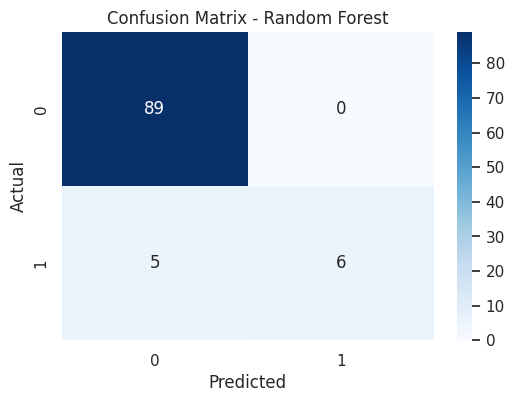

In [18]:
# ------------------------------------------------
# Cell 18: Confusion Matrix
# ------------------------------------------------

cm = confusion_matrix(y_test, forest_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
# ------------------------------------------------
# Cell 19: Save Model for Deployment Demo
# ------------------------------------------------

joblib.dump(
    random_forest_pipeline,
    "churn_model.pkl"
)

print("Model saved successfully as churn_model.pkl")

Model saved successfully as churn_model.pkl


In [20]:
# ------------------------------------------------
# Cell 20: Basic Deployment Demonstration
# ------------------------------------------------

# Load saved model
loaded_model = joblib.load("churn_model.pkl")

# Select one sample customer from test data
sample_customer = X_test.iloc[[0]]

# Make prediction
sample_prediction = loaded_model.predict(sample_customer)

print("DEPLOYMENT DEMO")
print("=" * 50)

print("Sample Customer Input:")
display(sample_customer)

print("Predicted Churn:", sample_prediction[0])

DEPLOYMENT DEMO
Sample Customer Input:


,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Customer_Lifetime_Value,Avg_Revenue_Per_Tenure,Tenure_Group,Contract_Risk,High_Value_Customer
58,36,38,3792,One year,Bank Transfer,Yes,1,1368,102.486486,25-48 Months,Low Risk,0


Predicted Churn: 0


In [21]:
# ------------------------------------------------
# Cell 21: Download Model and Cleaned Dataset
# ------------------------------------------------

files.download("churn_model.pkl")
files.download("cleaned_customer_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
# ------------------------------------------------
# Cell 22: Final Business Summary
# ------------------------------------------------

print("=" * 70)
print("FINAL CAPSTONE BUSINESS SUMMARY")
print("=" * 70)

print("Business Problem:")
print("Predict customer churn and provide data-driven retention recommendations.")

print("\nModels Used:")
print("1. Logistic Regression")
print("2. Random Forest Classifier")

print("\nBest Model:")
print("Random Forest Classifier")

print("\nKey Recommendations:")
print("1. Focus on high-risk customers with short tenure.")
print("2. Provide retention offers for month-to-month contract customers.")
print("3. Use churn prediction model for proactive customer support.")
print("4. Monitor customer behavior and update the model regularly.")
print("5. Build dashboards for business performance tracking.")

print("=" * 70)

FINAL CAPSTONE BUSINESS SUMMARY
Business Problem:
Predict customer churn and provide data-driven retention recommendations.

Models Used:
1. Logistic Regression
2. Random Forest Classifier

Best Model:
Random Forest Classifier

Key Recommendations:
1. Focus on high-risk customers with short tenure.
2. Provide retention offers for month-to-month contract customers.
3. Use churn prediction model for proactive customer support.
4. Monitor customer behavior and update the model regularly.
5. Build dashboards for business performance tracking.
